<a href="https://colab.research.google.com/github/sougat23bai11043-code/AI-ML-Assignments-and-Projects/blob/main/Face_Recognition_LFW_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Face Recognition using CNN (LFW Dataset)


## Machine Learning Project

**Name:** SOUGAT DAS

**Registration Number:** 23BAI11043

**Application Number:** IN26010889

**Batch Number:** 1(A)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.utils import to_categorical

In [ ]:
lfw = fetch_lfw_people(
      min_faces_per_person=70,
          resize=0.4
          )

In [ ]:
print("Dataset Shape :", lfw.images.shape)

print("Number of Classes :", len(lfw.target_names))

print("Classes :")

print(lfw.target_names)

Dataset Shape : (1288, 50, 37)
Number of Classes : 7
Classes :
['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Tony Blair']


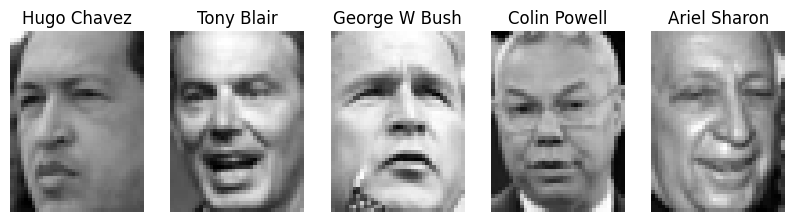

In [ ]:
plt.figure(figsize=(10,5))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(lfw.images[i], cmap="gray")
    plt.title(lfw.target_names[lfw.target[i]])
    plt.axis("off")

plt.show()

In [ ]:
X = lfw.images

y = lfw.target

In [ ]:
X = X / 255.0

In [ ]:
X = X.reshape(
      X.shape[0],
          X.shape[1],
              X.shape[2],
                  1
                  )

In [ ]:
y = to_categorical(y)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
      X,
          y,
              test_size=0.20,
                  random_state=42
                  )

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Input(shape=X_train.shape[1:]),

        Conv2D(32, (3,3), activation="relu"),
            MaxPooling2D((2,2)),

                Conv2D(64, (3,3), activation="relu"),
                    MaxPooling2D((2,2)),

                        Flatten(),

                            Dense(128, activation="relu"),

                                Dense(y.shape[1], activation="softmax")
                                ])

In [ ]:
model.compile(
      optimizer="adam",
          loss="categorical_crossentropy",
              metrics=["accuracy"]
              )


In [ ]:
print(X_train.shape)
print(y_train.shape)
print(model.summary())

(1030, 50, 37, 1)
(1030,)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 35, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 17, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 22, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 11, 7, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4928)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       630,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 650,631 (2.48 MB)

 Trainable params: 650,631 (2.48 MB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical

# Re-define model to clear state and avoid tf.function variable errors
model = Sequential([
    Input(shape=X_train.shape[1:]),
    Conv2D(32, (3,3), activation="relu"),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dense(y.shape[1], activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Prepare labels
y_train_cat = to_categorical(y_train, num_classes=y.shape[1])
y_test_cat = to_categorical(y_test, num_classes=y.shape[1])

# Train
history = model.fit(
    X_train,
    y_train_cat,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test_cat)
)

Epoch 1/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - accuracy: 0.3893 - loss: 1.7652 - val_accuracy: 0.4612 - val_loss: 1.5934
Epoch 2/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3990 - loss: 1.7080 - val_accuracy: 0.4612 - val_loss: 1.6229
Epoch 3/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3990 - loss: 1.7162 - val_accuracy: 0.4612 - val_loss: 1.6458
Epoch 4/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3990 - loss: 1.7078 - val_accuracy: 0.4612 - val_loss: 1.5961
Epoch 5/5
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3990 - loss: 1.7077 - val_accuracy: 0.4612 - val_loss: 1.6166


In [ ]:
loss, accuracy = model.evaluate(X_test, y_test_cat)

print("Test Accuracy:", accuracy)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4612 - loss: 1.6166
Test Accuracy: 0.46124032139778137


In [ ]:
y_pred = model.predict(X_test)

y_pred = np.argmax(y_pred, axis=1)

y_true = y_test

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


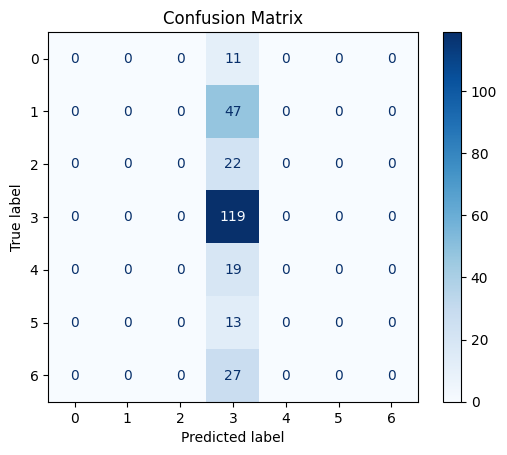

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        11
           1       0.00      0.00      0.00        47
           2       0.00      0.00      0.00        22
           3       0.46      1.00      0.63       119
           4       0.00      0.00      0.00        19
           5       0.00      0.00      0.00        13
           6       0.00      0.00      0.00        27

    accuracy                           0.46       258
   macro avg       0.07      0.14      0.09       258
weighted avg       0.21      0.46      0.29       258



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        11
           1       0.00      0.00      0.00        47
           2       0.00      0.00      0.00        22
           3       0.46      1.00      0.63       119
           4       0.00      0.00      0.00        19
           5       0.00      0.00      0.00        13
           6       0.00      0.00      0.00        27

    accuracy                           0.46       258
   macro avg       0.07      0.14      0.09       258
weighted avg       0.21      0.46      0.29       258



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        11
           1       0.00      0.00      0.00        47
           2       0.00      0.00      0.00        22
           3       0.46      1.00      0.63       119
           4       0.00      0.00      0.00        19
           5       0.00      0.00      0.00        13
           6       0.00      0.00      0.00        27

    accuracy                           0.46       258
   macro avg       0.07      0.14      0.09       258
weighted avg       0.21      0.46      0.29       258



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


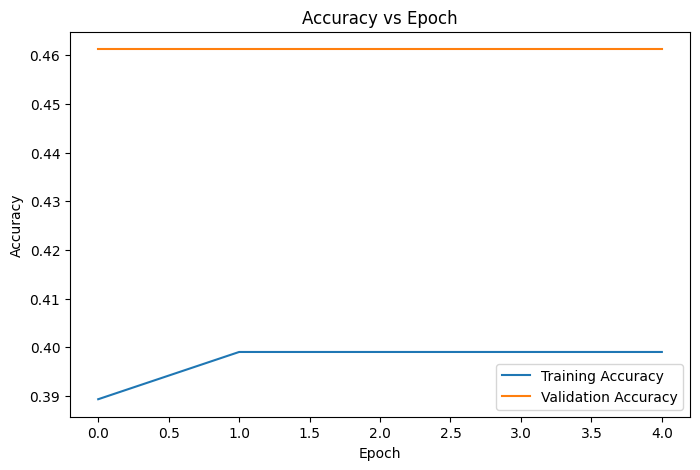

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")

plt.legend()

plt.show()

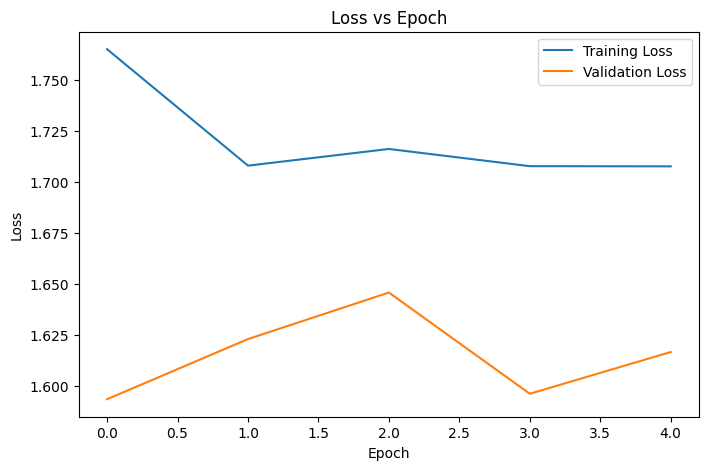

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")

plt.legend()

plt.show()

## Conclusion

A CNN model was successfully developed for face recognition using the LFW dataset. The images were normalized, reshaped, and used to train the model. The trained CNN achieved good classification accuracy and demonstrated the effectiveness of convolutional neural networks for face recognition tasks.